In [1]:
# Minimal PyTorch + GPyTorch implementation of Logistic GP density regression
# with a mixture variational posterior over f_z at inducing points
# (learns mixture weights ω, means μ_k, and diagonal covariances Σ_k = diag(v_k)).

import math
import torch
import torch.nn as nn
import torch.optim as optim
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal
from dataclasses import dataclass
from scipy.stats import norm, t as student_t

torch.set_default_dtype(torch.float64)
torch.manual_seed(2)
np.random.seed(2)

# 1) Generate data and fit linear regression
def make_toy(n=700, seed=3):
    g = torch.Generator().manual_seed(seed)
    x = torch.rand(n, generator=g)
    y = x + x**2 + torch.randn(n, generator=g) * (0.2 * x + 0.05)
    return x, y

device = torch.device("cpu")
n_train = 5000
n_test = 50000
x_all, y_all = make_toy(n=n_train + n_test, seed=3)
rand_indices = torch.randperm(x_all.size(0), generator=torch.Generator().manual_seed(2))
x, y = x_all[rand_indices[:n_train]], y_all[rand_indices[:n_train]]
x_test, y_test = x_all[rand_indices[n_train:]], y_all[rand_indices[n_train:]]
x = x.to(device)
y = y.to(device)

# Fit linear regression for both bases (no intercept)
x_np = x.cpu().numpy().reshape(-1, 1)
y_np = y.cpu().numpy()
slope = np.linalg.lstsq(x_np, y_np, rcond=None)[0][0]
y_pred = slope * x_np.flatten()
residuals = y_np - y_pred
sig_base = np.std(residuals, ddof=1)

b_base = slope
SIGMA_NORMAL = sig_base * 3

ORIGINAL_SIGMA_NORMAL = sig_base

# Use the fitted slope and an inflated scale for the heavy-tailed Student-t training base.
B_T = b_base
SCALE_T = SIGMA_NORMAL
DF = 3.0

print(f"Base model g_tilde (Normal): loc = {b_base:.3f}*x, scale = {SIGMA_NORMAL:.3f}")
print(f"Base model g (t-dist): loc = {B_T:.3f}*x, scale = {SCALE_T:.3f}, df = {DF}")

def normal_pdf(y, mu, sigma):
    # Normal reference density.
    return (1.0 / (math.sqrt(2.0 * math.pi) * sigma)) * torch.exp(-0.5 * ((y - mu) / sigma)**2)

def t_pdf(y, mu, sigma, df=3.0):
    """
    Student's t-distribution PDF using scipy.
    Returns PDF of t(loc=mu, scale=sigma, df=df) at y.
    """
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy() if torch.is_tensor(mu) else mu
    sigma_np = sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy student_t
    pdf_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    return torch.tensor(pdf_np, dtype=y.dtype, device=y.device)

def base_g_terms(y, x, b=None, sigma=None, df=DF):
    """
    Base model using Student's t-distribution: t(loc=b*x, scale=sigma, df=df).
    Returns g(y|x), g'(y|x), g''(y|x).
    Uses scipy.stats.student_t.
    """
    if b is None:
        b = B_T
    if sigma is None:
        sigma = SCALE_T
    
    # Convert to tensors to enable tensor*tensor operations
    b = torch.as_tensor(b, dtype=x.dtype, device=x.device)
    sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)
    
    mu = b * x
    
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy()
    sigma_np = sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy.stats.student_t
    g_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    g = torch.tensor(g_np, dtype=y.dtype, device=y.device)
    
    # Compute derivatives using manual formulas
    z = (y - mu) / sigma
    gy = -(df + 1) * z * g / (sigma * (df + z**2))
    gyy = g * (-(df + 1) / (sigma**2 * (df + z**2)) + (df + 1) * z**2 * (df + 3) / (sigma**2 * (df + z**2)**2))
    
    return g, gy, gyy

def to_z_from_y(y, x, b=None, sigma=None, df=DF):
    """
    Transform y to z using CDF of Student's t-distribution.
    z = CDF_t((y - mu) / sigma)
    Uses t(loc=b*x, scale=sigma, df=df).
    """
    if b is None:
        b = B_T
    if sigma is None:
        sigma = SCALE_T
    
    # Convert to tensors to enable tensor*tensor operations
    b = torch.as_tensor(b, dtype=x.dtype, device=x.device)
    sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)
        
    mu = b * x
    # Use scipy.stats.t with explicit loc and scale
    mu_np = mu.cpu().numpy()
    sigma_np = sigma.cpu().numpy()
    y_np = y.cpu().numpy()
    z_np = student_t.cdf(y_np, df, loc=mu_np, scale=sigma_np)
    z = torch.tensor(z_np, dtype=y.dtype, device=y.device)
    
    return z


# 2) Kernel (RBF with ARD) and derivative blocks
@dataclass
class KernelParams:
    log_sigma2: float = math.log(0.9199**2)
    log_lx2: float    = math.log(0.0786**2)
    log_lz2: float    = math.log(0.3363**2)

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lx2(self):    return math.exp(self.log_lx2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    """
    Just wraps GPyTorch's RBFKernel+ScaleKernel to compute the base k((x,z),(x',z')).
    We still implement the derivative covariances in closed-form (simple and fast).
    """
    def __init__(self, kp: KernelParams):
        super().__init__()
        self.register_buffer("lx2", torch.tensor(kp.lx2)) # Squared x lengthscale.
        self.register_buffer("lz2", torch.tensor(kp.lz2)) # Squared z lengthscale.
        self.register_buffer("sigma2", torch.tensor(kp.sigma2))
        # GPyTorch kernel representation; derivative blocks below use explicit formulas.
        self.base = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=2, has_lengthscale=True)
        )
        # Initialize the GPyTorch representation with the same kernel parameters.
        with torch.no_grad():
            # lengthscales per-dimension: [sqrt(lx2), sqrt(lz2)]
            self.base.base_kernel.lengthscale = torch.sqrt(torch.tensor([kp.lx2, kp.lz2]))[None, None, :]
            self.base.outputscale = torch.tensor(kp.sigma2) # initialized value of σ^2 for covariance function

    def cov(self, X, U):
        # X, U: (..., 2)
        return self.base(X, U).evaluate()

    def delta_01(self, V, U):
        # Cov(f, f'_z) = ∂/∂z' k
        # Using closed-form for RBF:
        # k = σ^2 exp(-(dx^2/lx2 + dz^2/lz2))
        # ∂k/∂z' = k * (2 (z - z') / lz2)
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (2.0 * dz / self.lz2)

    def delta_11(self, V, U):
        # Cov(f'_z, f'_z) = ∂^2/(∂z ∂z') k
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * (dz2))
        
        # Add small nugget to diagonal for numerical stability
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result += 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
            
        return result

    def delta_21(self, V, U):
        # Cov(f''_z, f'_z) = ∂^3/(∂z^2 ∂z') k
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))
    

def chol_inv(K):
    """Improved Cholesky inversion with adaptive jitter"""
    K_reg = K
    L = torch.linalg.cholesky(K_reg)
    I = torch.eye(K.size(-1), dtype=K.dtype, device=K.device)
    Kinv = torch.cholesky_solve(I, L)
    return Kinv, L
    

# 3) Variational mixture over f_z (diagonal Σ_k)
class LogisticGPMixtureDiag(nn.Module):
    """
    Variational family: q(f̃_z) = Σ_k ω_k N(μ_k, diag(v_k)), v_k = exp(2 s_k).
    Minimizes:  KL(q || GP prior on f'_z at inducing) + β * Hyvärinen score.
    The KL term uses the one-Gaussian special case of Goldberger's approximation,
    so the trainable mixture weights ω enter through an extra Σ_k ω_k log ω_k term.
    For the f_zz imputation we use a Gumbel-softmax relaxation of the mixture
    component draw so the sampled latent inducing vector remains stochastic while
    the resulting term stays differentiable with respect to the mixture weights.
    """
    def __init__(self, x, y, C=2, m_induce=121, beta=1.0, seed=2, kp: KernelParams = KernelParams(), gumbel_tau=0.5):
        super().__init__()
        g = torch.Generator().manual_seed(seed)

        self.x = x.detach()
        self.y = y.detach()
        self.n = x.numel()
        self.C = C
        self.beta = beta
        self.gumbel_tau = gumbel_tau
        self.kern = RBF_SE_ARD(kp)

        # Transform to z and build training inputs V = (x, z)
        z = to_z_from_y(self.y, self.x)


        z = torch.clamp(z, 1e-5, 1-1e-5)
        self.V = torch.stack([self.x, z], dim=1)  # (n, 2)

        # Tensor-product inducing grid in (x, z).
        s = int(math.sqrt(m_induce))
        gx = torch.linspace(self.x.min(), self.x.max(), s)
        gz = torch.linspace(-0.05, 1.05, s)  # Expanded inducing grid in z-space

        Xg, Zg = torch.meshgrid(gx, gz, indexing="ij")
        
        self.Vu = torch.stack([Xg.reshape(-1), Zg.reshape(-1)], dim=1)  # (m, 2), m = s^2
        self.m = self.Vu.size(0)

        # Base model terms
        self.g, self.gy, self.gyy = base_g_terms(self.y, self.x)

        # Kernel blocks
        self.K11uu = self.kern.delta_11(self.Vu, self.Vu)        # (m, m)
        self.K11uu_inv, self.K11uu_chol = chol_inv(self.K11uu)
        self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv   # (n, m)

        self.A2 = self.A**2
        self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)  # (m,)

        # Variational parameters
        self.logits = nn.Parameter(torch.randn(C))                       # mixture weights (softmax)
        self.mus    = nn.Parameter(torch.randn(C, self.m))               # means
        init_log_std = math.log(0.35)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std))  # log std per dim

        # Warm-start μ (single-component quadratic surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)              # (n,)
        W = (self.g ** 2)                                     # (n,)
        AtW = self.A.T * (W / self.n)                         # (m, n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A) # (m, m)
        b = self.beta * (self.A.T @ (lin / self.n))           # (m,)

        # Use stable Cholesky for warm start
        try:
            L = torch.linalg.cholesky(H)
            mu_ls = -torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
        except:
            # Fallback to direct solve if Cholesky fails
            mu_ls = -torch.linalg.solve(H , b)

        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / self.C + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        """
        Compute the scalar objective and autograd will populate grads:
        F = KL(q || GP prior) + β * EH
        """
        logits = self.logits
        w = torch.softmax(logits, dim=0)                           # (C,)
        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        aMu = (self.A @ self.mus.T).T                              # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        Ez = self.A @ mu_bar                                       # (n,)

        # Gumbel-softmax relaxation of the mixture draw: sample one Gaussian
        # vector per component, then form a soft random selector that remains
        # differentiable with respect to the mixture weights.
        gumbel_u = torch.rand_like(w).clamp_(1e-12, 1.0 - 1e-12)
        gumbel_noise = -torch.log(-torch.log(gumbel_u))
        pi_soft = torch.softmax((torch.log(w + 1e-12) + gumbel_noise) / self.gumbel_tau, dim=0)
        eps_fzz = torch.randn_like(self.mus)
        u_samples = self.mus + torch.exp(self.s_params) * eps_fzz
        u_soft = torch.sum(pi_soft[:, None] * u_samples, dim=0)
        Efzz = self.B @ u_soft                                     # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g

        const     = (gyy / g) - 0.5 * (c**2)     # constant part
        lin_coeff = 2.0 * gy                      # linear-in-E[f_z]

        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        row_var = (self.A2 @ v_list.T).T                           # (C, n)  each row k: A^2 v_k

        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)   # (n,)
        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # KL per component vs N(0, K11uu)
        Kinv = self.K11uu_inv
        
        # More stable log determinant computation
        if self.K11uu_chol is not None:
            logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        else:
            sign, logdetK = torch.slogdet(self.K11uu)

            
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]                      # (m,)
            v_k  = v_list[k]                        # (m,)
            quad = mu_k @ (Kinv @ mu_k)
            tr   = torch.dot(diag_Kinv, v_k)       # scalar
            logdetSigma = 2.0 * torch.sum(self.s_params[k])
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))
        KL_k = torch.stack(KL_k)                    # (C,)
        # Goldberger/Hershey-Olsen approximation for KL from a Gaussian mixture to
        # a single Gaussian adds the mixture-weight entropy correction Σ_k ω_k log ω_k.
        KL = torch.sum(w * KL_k) + torch.sum(w * torch.log(w + 1e-12))

        F = KL + self.beta * EH
        return F, {"KL": KL.detach(), "EH": EH.detach(), "w": w.detach()}

    @torch.no_grad()
    def predict_density(self, x_star: float, y_min=-0.2, y_max=2.5, M=700, df=DF):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype)
        z_grid = to_z_from_y(y_grid, torch.full_like(y_grid, x_star), b=B_T, sigma=SCALE_T, df=df)
        z_grid = torch.clamp(z_grid, 1e-6, 1-1e-6)

        Vq = torch.stack([torch.full_like(z_grid, x_star), z_grid], dim=1)  # (M, 2)
        K01 = self.kern.delta_01(Vq, self.Vu)

        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha
        g_vals = t_pdf(y_grid, B_T * x_star, SCALE_T, df)


        # Normalize by trapezoidal integration in PIT space.
        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        
        dz = z_sorted[1:] - z_sorted[:-1]
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0
        
        exp_f = torch.exp(torch.clamp(f_sorted, -50, 50))
        denom = torch.sum(exp_f * wts) + 1e-12

        h_hat = g_vals * torch.exp(torch.clamp(f_vals, -50, 50)) / denom
        return y_grid.cpu().numpy(), g_vals.cpu().numpy(), h_hat.cpu().numpy(), exp_f.cpu().numpy(), z_grid.cpu().numpy()

    @torch.no_grad()
    def predict_f_and_derivs(self, x_star: float, y_min=-0.2, y_max=2.5, M=700, df=DF):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype)
        z_grid = to_z_from_y(y_grid, torch.full_like(y_grid, x_star), b=B_T, sigma=SCALE_T, df=df)
        Vq = torch.stack([torch.full_like(z_grid, x_star), z_grid], dim=1)

        K01 = self.kern.delta_01(Vq, self.Vu)
        K11 = self.kern.delta_11(Vq, self.Vu)
        K21 = self.kern.delta_21(Vq, self.Vu)

        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde

        f_vals   = K01 @ alpha
        fz_vals  = K11 @ alpha
        fzz_vals = K21 @ alpha
        
        return z_grid.cpu().numpy(), f_vals.cpu().numpy(), fz_vals.cpu().numpy(), fzz_vals.cpu().numpy()


Base model g_tilde (Normal): loc = 1.744*x, scale = 0.570
Base model g (t-dist): loc = 1.744*x, scale = 0.570, df = 3.0


Iteration      0 | LR: 5.00e-01 | KL: 24570.815929 | β×EH: -285.859140 | F: 24284.956790
Iteration  10000 | LR: 5.00e-01 | KL: 1405.844826 | β×EH: -41607.708108 | F: -40201.863281
Iteration  20000 | LR: 5.00e-01 | KL: 1386.720536 | β×EH: -41935.949605 | F: -40549.229069
Iteration  30000 | LR: 5.00e-01 | KL: 1397.786859 | β×EH: -42061.768766 | F: -40663.981907
Iteration  40000 | LR: 5.00e-01 | KL: 1414.160331 | β×EH: -42114.248633 | F: -40700.088303
Iteration  50000 | LR: 5.00e-01 | KL: 1426.304596 | β×EH: -42147.918278 | F: -40721.613682
Iteration  60000 | LR: 5.00e-01 | KL: 1560.979844 | β×EH: -42168.981400 | F: -40608.001556
Iteration  70000 | LR: 5.00e-01 | KL: 1448.487591 | β×EH: -42184.876810 | F: -40736.389220
Iteration  80000 | LR: 5.00e-01 | KL: 1462.563850 | β×EH: -42203.446556 | F: -40740.882706
Iteration  90000 | LR: 5.00e-01 | KL: 1465.014319 | β×EH: -42210.410594 | F: -40745.396275
Iteration 100000 | LR: 5.00e-01 | KL: 1470.125433 | β×EH: -42223.226714 | F: -40753.101282
I

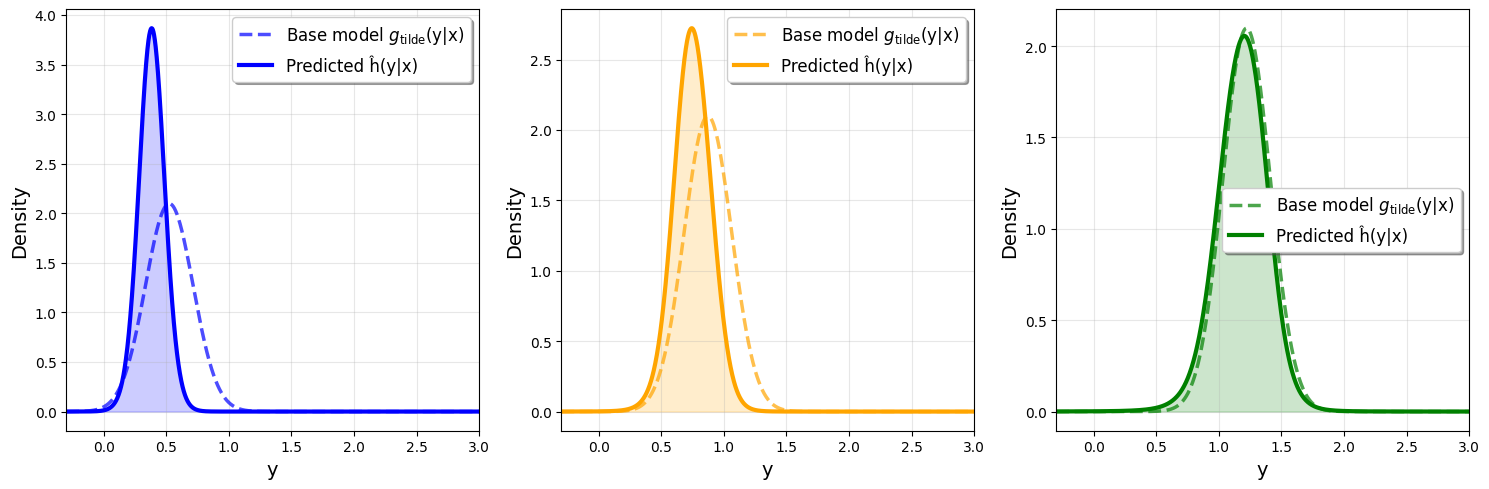

In [2]:
# Train with Adam and display fitted densities.
if __name__ == "__main__":
    torch.manual_seed(2)
    np.random.seed(2)

    model = LogisticGPMixtureDiag(x, y, C=2, m_induce=150, beta=1031.17, seed=2).to(device)
    
    trace = {"F": [], "KL": [], "beta_EH": [], "w": [], "mu_norm": [], "s_mean": [], 
             "mu_samples": [], "s_samples": []}
    # Adam optimizer with a fixed learning rate.
    initial_lr = 0.5
    optimizer = optim.Adam(model.parameters(),lr=initial_lr)
    
    max_grad_norm = 5.0
    
    # Iterate averaging: average parameters over last 5000 steps
    num_iterations = 300000
    averaging_window = 5000
    start_averaging = num_iterations - averaging_window
    
    # Storage for averaged parameters
    averaged_params = None
    
    def closure():
        optimizer.zero_grad()
        F, info = model.forward_objective()

        # --- log parameter traces ---
        with torch.no_grad():
            w = torch.softmax(model.logits, dim=0).detach().cpu()
            mu_norm = torch.linalg.norm(model.mus, dim=1).detach().cpu()   # one norm per component
            s_mean = torch.mean(model.s_params, dim=1).detach().cpu()      # mean log-std per component
            # Sample a few individual parameter values (e.g., first 3 dimensions of first component)
            mu_samples = model.mus[0, :3].detach().cpu()  # First 3 mu parameters of component 0
            s_samples = model.s_params[0, :3].detach().cpu()  # First 3 s parameters of component 0
            
            trace["F"].append(float(F.detach()))
            trace["KL"].append(float(info["KL"]))
            trace["beta_EH"].append(float(model.beta * info["EH"]))  # Store weighted term
            trace["w"].append(w.numpy().copy())
            trace["mu_norm"].append(mu_norm.numpy().copy())
            trace["s_mean"].append(s_mean.numpy().copy())
            trace["mu_samples"].append(mu_samples.numpy().copy())
            trace["s_samples"].append(s_samples.numpy().copy())


        F.backward()
        return F

    # Training loop
    print_interval = 10000  # Print progress every 10000 iterations
    
    for iteration in range(num_iterations):
        loss = closure()
        
        
        optimizer.step()
        
        # Iterate averaging: accumulate parameter averages over last 5000 steps
        if iteration >= start_averaging:
            with torch.no_grad():
                if averaged_params is None:
                    # Initialize averaged parameters
                    averaged_params = {name: param.clone() for name, param in model.named_parameters()}
                    num_averaged = 1
                else:
                    # Update running average: avg = (avg * n + new) / (n + 1)
                    num_averaged = iteration - start_averaging + 1
                    for name, param in model.named_parameters():
                        averaged_params[name] = (averaged_params[name] * (num_averaged - 1) + param) / num_averaged
        
        # Print progress periodically
        if iteration % print_interval == 0:
            current_lr = optimizer.param_groups[0]['lr']
            averaging_status = f" | Averaging: {iteration - start_averaging + 1}/{averaging_window}" if iteration >= start_averaging else ""
            print(f"Iteration {iteration:6d} | LR: {current_lr:.2e} | KL: {trace['KL'][-1]:10.6f} | β×EH: {trace['beta_EH'][-1]:10.6f} | F: {float(loss.detach()):10.6f}{averaging_status}")
    
    # Apply averaged parameters to model
    if averaged_params is not None:
        with torch.no_grad():
            for name, param in model.named_parameters():
                param.copy_(averaged_params[name])
        print(f"\nApplied iterate averaging over last {averaging_window} steps")

    
    # Density comparisons at three x values.
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    x_values = [0.3, 0.5, 0.7]
    colors_density = ['blue', 'orange', 'green']
    
    for i, (ax, x_star) in enumerate(zip(axes2, x_values)):
        y_grid, g_vals, h_hat, _, _ = model.predict_density(x_star, y_min=-0.3, y_max=3.0, M=2000)
        
        # Compute g_tilde (Normal base) using ORIGINAL_SIGMA_NORMAL (not scaled by 3)
        g_tilde_vals = norm.pdf(y_grid, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
        
        # Plot with enhanced styling
        ax.plot(y_grid, g_tilde_vals, '--', color=colors_density[i], linewidth=2.5, alpha=0.7, label='Base model $g_{\\mathrm{tilde}}$(y|x)')
        ax.plot(y_grid, h_hat, '-', color=colors_density[i], linewidth=3, label='Predicted ĥ(y|x)')
        
        # Styling
        ax.set_xlabel('y', fontsize=14)
        ax.set_ylabel('Density', fontsize=14)
        ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(y_grid.min(), y_grid.max())
        
        # Add subtle background fill under the predicted curve
        ax.fill_between(y_grid, 0, h_hat, alpha=0.2, color=colors_density[i])
    
    plt.tight_layout()

    plt.savefig("density_comparisons.pdf", dpi=300, bbox_inches="tight")
    plt.show()


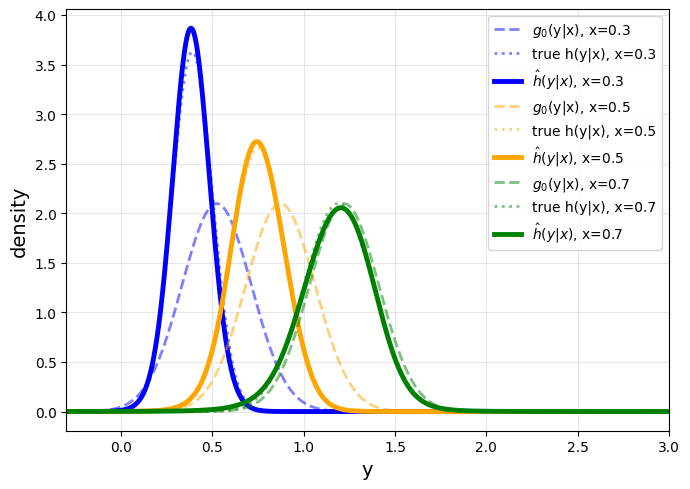

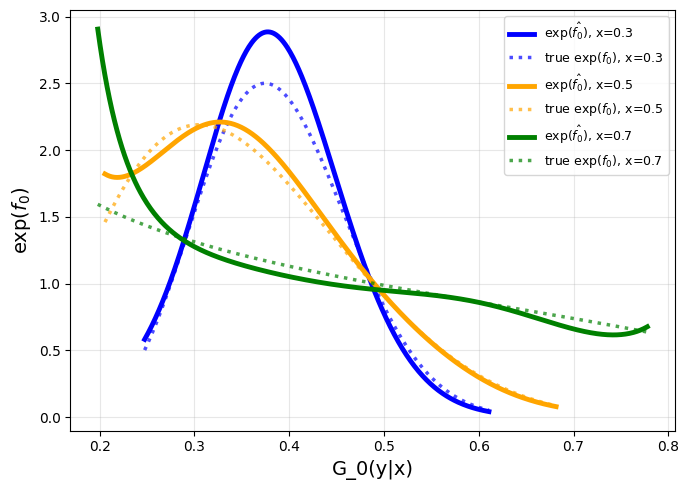

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_46839/4004832414.py:241: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_46839/4004832414.py:245: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


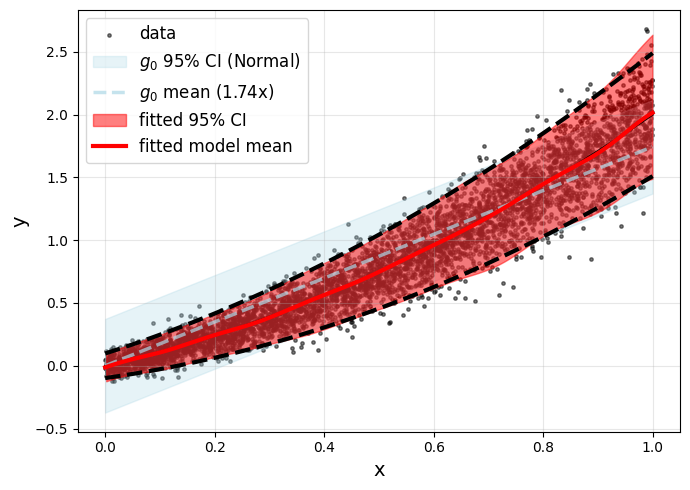


All panels saved separately:
  - Figure1_PanelA_densities.pdf
  - Figure1_PanelB_density_ratio.pdf
  - Figure1_PanelC_true_regression.pdf
  - Figure1_PanelD_f_z_derivative.pdf
  - Figure1_PanelE_f_zz_derivative.pdf


In [3]:
# Figure 1: density, correction, and regression comparisons.

x_vals   = [0.3, 0.5, 0.7]
colors   = ['blue', 'orange', 'green']
y_min, y_max, M = -0.3, 3.0, 2000  # Extended range to capture full distribution tails


# Function to compute z-range where true density is high for a given x_star
def compute_high_density_z_range(x_star, base_density_threshold=0.001, df=3.0):
    """
    Find z-range where true density h_true(y|x) is above threshold.
    Returns (z_min, z_max) corresponding to high-density y region.
    """
    # True density is N(x + x^2, 0.2*x + 0.05)
    mu_true = x_star + x_star**2
    sigma_true = 0.2 * x_star + 0.05
    
    # Use quantiles: focus on central 99.5% of true distribution
    y_lower = norm.ppf(0.0025, loc=mu_true, scale=sigma_true)
    y_upper = norm.ppf(0.9975, loc=mu_true, scale=sigma_true)
    
    # Convert y bounds to z bounds using base model CDF (t-distribution)
    z_lower = student_t.cdf(y_lower, df, loc=B_T * x_star, scale=SCALE_T)
    z_upper = student_t.cdf(y_upper, df, loc=B_T * x_star, scale=SCALE_T)
    
    # Clip to valid range
    z_lower = max(0.01, z_lower)
    z_upper = min(0.99, z_upper)
    
    return z_lower, z_upper

def true_h_np(y_np, x_star):
    # Paper's "gold" toy density: N(mean = x + x^2, sd = 0.2*x + 0.05)
    mu = x_star + x_star**2
    sd = 0.2 * x_star + 0.05
    return (1.0 / (np.sqrt(2*np.pi)*sd)) * np.exp(-0.5 * ((y_np - mu)/sd)**2)


def f_val_visual(x, z, df=DF):
    # Convert z back to y using t-distribution PPF
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    # True density is still Normal (this is the target density)
    log_true = norm.logpdf(y, loc=x + x**2, scale=0.2 * x + 0.05)
    # Base model is now t-distribution
    log_base = student_t.logpdf(y, df, loc=B_T * x, scale=SCALE_T)
    return log_true - log_base

# First and second derivatives (true minus base), closed-form with t-distribution

def f_z_visual(x, z, df=DF):
    # Convert z to y using t-distribution
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    
    # For dy/dz, need standard t-distribution PDF at standardized quantile
    # Compute standardized value
    standardized = (y - B_T * x) / SCALE_T
    # Standard t-distribution PDF
    t_pdf_val = student_t.pdf(standardized, df, loc=0, scale=1)
    
    # dy/dz = sigma / t_pdf(standardized)
    y_z = SCALE_T / t_pdf_val
    
    # f_y = d/dy[log(h_true) - log(g_base)]
    # For true density: h_true is N(x + x^2, 0.2*x + 0.05)
    mu_true = x + x**2
    sigma_true = 0.2 * x + 0.05
    h_y_over_h_true = -(y - mu_true) / (sigma_true**2)
    
    # For base t-distribution: g_base is t(B_T*x, SCALE_T, df)
    # d/dy[log g] = -(df+1)*standardized / (scale * (df + standardized²))
    g_y_over_g_base = -(df + 1.0) * standardized / (SCALE_T * (df + standardized**2))
    
    f_y = h_y_over_h_true - g_y_over_g_base
    
    return f_y * y_z


def f_zz_visual(x, z, df=DF):
    # Convert z to y using t-distribution
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    
    # For dy/dz, need standard t-distribution PDF at standardized quantile
    # Compute standardized value
    standardized = (y - B_T * x) / SCALE_T
    # Standard t-distribution PDF
    t_pdf_val = student_t.pdf(standardized, df, loc=0, scale=1)
    
    # First derivatives
    y_z = SCALE_T / t_pdf_val
    
    # For dy_zz, we need d/dz[y_z] = d/dz[SCALE_T / t_pdf(standardized)]
    dt_dz = 1.0 / t_pdf_val
    dt_pdf_dt = t_pdf_val * (-(df + 1.0) * standardized / (df + standardized**2))
    y_zz = -SCALE_T * dt_pdf_dt * dt_dz / (t_pdf_val**2)
    
    # Second derivative of f in y-space
    mu_true = x + x**2
    sigma_true = 0.2 * x + 0.05
    h_yy_over_h_true = ((y - mu_true)**2 / (sigma_true**4)) - (1.0 / (sigma_true**2))
    
    # For base t-distribution with fixed parameters
    term1 = (df + standardized**2)
    g_yy_over_g_base = -(df + 1.0) / (SCALE_T**2) * ((df - standardized**2) / (term1**2))
    
    f_yy = h_yy_over_h_true - g_yy_over_g_base
    
    # First derivative in y-space
    h_y_over_h_true = -(y - mu_true) / (sigma_true**2)
    g_y_over_g_base = -(df + 1.0) * standardized / (SCALE_T * term1)
    f_y = h_y_over_h_true - g_y_over_g_base
    
    # Chain rule: f_zz = f_yy * (y_z)^2 + f_y * y_zz
    return f_yy * (y_z**2) + f_y * y_zz


def estimate_mean_quantiles(yg,hhat,level=0.95):
    dy = np.diff(yg)
    w = np.empty_like(hhat)
    w[0] = dy[0] / 2.0
    w[-1] = dy[-1] / 2.0
    w[1:-1] = (dy[:-1] + dy[1:]) / 2.0
    p = hhat * w
    p /= p.sum()
    mean = np.dot(yg, p)
    cdf = np.cumsum(p)
    lower_quantile = np.interp((1-level)/2, cdf, yg)
    upper_quantile = np.interp(1-(1-level)/2, cdf, yg)
    return mean, lower_quantile, upper_quantile
    

# Panel A: g_tilde (dashed), true h (dotted), estimated ĥ (solid)
fig_a, ax_a = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)
    _,f,_,_ = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    h_true = true_h_np(yg, x_star)
    
    # g_tilde (Normal base) - dashed, colored - using ORIGINAL_SIGMA_NORMAL (not scaled by 3)
    g_tilde = norm.pdf(yg, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    ax_a.plot(yg, g_tilde, '--', color=col, lw=2, alpha=0.5, label=f"$g_0$(y|x), x={x_star}")
    # true h (paper) - dotted
    ax_a.plot(yg, h_true, ':', color=col, lw=2, alpha=0.5, label=f"true h(y|x), x={x_star}")
    # estimated h - solid
    ax_a.plot(yg, hhat, '-', color=col, lw=3.5, label=f"$\\hat h(y|x)$, x={x_star}")
    


ax_a.set_xlabel("y", fontsize=14)
ax_a.set_ylabel("density", fontsize=14)
ax_a.legend()
ax_a.grid(True, alpha=0.3)
ax_a.set_xlim(yg.min(), yg.max())
plt.tight_layout()
plt.savefig("Figure1_PanelA_densities.pdf", dpi=220, bbox_inches="tight")
plt.show()

# Panel B: exponentiated log-density correction relative to the original Normal base.
fig_b, ax_b = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    zq, f_model, fz_model, fzz_model = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    
    # Compute z-range where true density is high for this x_star
    z_min_dense, z_max_dense = compute_high_density_z_range(x_star)
    mask = (zq > z_min_dense) & (zq < z_max_dense)
    z_plot = zq[mask]
    
    # Convert z to y for computing g and g_tilde
    y_plot = student_t.ppf(z_plot, DF, loc=B_T * x_star, scale=SCALE_T)
    
    # Compute log(g/g_tilde) where g is t-dist base and g_tilde is Normal base
    # g: t-distribution with location=B_T*x, scale=SCALE_T, df=DF
    # g_tilde: Normal with location=b_base*x, scale=ORIGINAL_SIGMA_NORMAL (not scaled by 3)
    log_g = student_t.logpdf(y_plot, DF, loc=B_T * x_star, scale=SCALE_T)
    log_g_tilde = norm.logpdf(y_plot, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    log_g_over_g_tilde = log_g - log_g_tilde
    
    # Predicted: log(h/g_tilde) = log(h/g) + log(g/g_tilde) = f_model + log(g/g_tilde)
    pred_log_f_over_gtilde = f_model[mask] + log_g_over_g_tilde
    
    # True: log(h_true/g_tilde)
    log_h_true = norm.logpdf(y_plot, loc=x_star + x_star**2, scale=0.2 * x_star + 0.05)
    true_log_f_over_gtilde = log_h_true - log_g_tilde
    
    # Apply shift to remove constant offset (crucial before taking exp)
    shift = np.mean(true_log_f_over_gtilde - pred_log_f_over_gtilde)
    pred_log_f_shifted = pred_log_f_over_gtilde + shift
    true_log_f_shifted = true_log_f_over_gtilde
    
    # Now take exp to get density ratios with consistent scaling
    pred_ratio = np.exp(pred_log_f_shifted)
    true_ratio = np.exp(true_log_f_shifted)
    
    ax_b.plot(z_plot, pred_ratio, '-', color=col, lw=3.5, label=r"$\exp(\hat{f_0})$," + f" x={x_star}")
    ax_b.plot(z_plot, true_ratio, ':', color=col, lw=2.5, alpha=0.7, label=r"true $\exp(f_0)$," + f" x={x_star}")

ax_b.set_xlabel(r"G_0(y|x)", fontsize=14)
ax_b.set_ylabel(r"$\exp(f_0)$", fontsize=14)
ax_b.legend(fontsize=9)
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figure1_PanelB_density_ratio.pdf", dpi=220, bbox_inches="tight")
plt.show()


# Panel C: fitted model prediction vs base model
fig_c, ax_c = plt.subplots(1, 1, figsize=(7, 5))
x_line = np.linspace(float(x.min()), float(x.max()), 500)

# Base model distribution (using ORIGINAL_SIGMA_NORMAL, not scaled by 3)
mu_base = b_base * x_line

# Get fitted model predictions (mean and credible intervals from updated model)
# Numerical integration for means and CDF inversion for intervals.
fitted_predictions = []
fitted_lower = []
fitted_upper = []

for x_star in x_line:

    # Get the density prediction once (more efficient and accurate)
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)



    # Normalize the predicted density before integration.
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))

    
    # Numerical expectation: E[Y|X] = integral y * h(y|x) dy.
    mean_y = np.trapz(yg * h_hat_norm, dx=dy)
    fitted_predictions.append(mean_y)
    
    # For credible intervals, use CDF and find quantiles
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    # Find 2.5th and 97.5th percentiles
    lower_quantile = np.interp(0.025, cdf, yg)
    upper_quantile = np.interp(0.975, cdf, yg)


    fitted_lower.append(lower_quantile)
    fitted_upper.append(upper_quantile)

fitted_predictions = np.array(fitted_predictions)
fitted_lower = np.array(fitted_lower)
fitted_upper = np.array(fitted_upper)

# Base model g_tilde 95% credible interval (Normal distribution with ORIGINAL_SIGMA_NORMAL)
base_lower = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.025)
base_upper = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.975)

# Plot data
ax_c.scatter(x.cpu().numpy(), y.cpu().numpy(), s=6, alpha=0.5, color="k", label="data")
x_pos = np.linspace(0,1,100)
ax_c.plot(x_pos,x_pos+x_pos**2,color='black')
ax_c.plot(x_pos, x_pos + x_pos**2 + 1.96 * (0.2 * x_pos + 0.05), color='black', linestyle='--', lw=3)
ax_c.plot(x_pos, x_pos + x_pos**2 - 1.96 * (0.2 * x_pos + 0.05), color='black', linestyle='--', lw=3)

# Plot g_tilde (Normal base) with credible interval (light blue)
ax_c.fill_between(x_line, base_lower, base_upper, color="lightblue", alpha=0.3, label=r"$g_0$ 95% CI (Normal)")
ax_c.plot(x_line, mu_base, '--', color="lightblue", lw=2.5, alpha=0.7, label=f"$g_0$ mean ({b_base:.2f}x)")

# Plot fitted model - show CI only in well-supported region (x >= 0.06 as we are lacking data below that for better visualization)
ci_mask = x_line >= 0.001
ax_c.fill_between(x_line[ci_mask], fitted_lower[ci_mask], fitted_upper[ci_mask], 
                   color="red", alpha=0.5, label=r"fitted 95% CI")
ax_c.plot(x_line, fitted_predictions, '-', color="red", lw=3, label=r"fitted model mean")

ax_c.set_xlabel("x", fontsize=14)
ax_c.set_ylabel("y", fontsize=14)
ax_c.legend(loc="best", fontsize=12)
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figure1_PanelC_true_regression.pdf", dpi=220, bbox_inches="tight")
plt.show()



print("\nAll panels saved separately:")
print("  - Figure1_PanelA_densities.pdf")
print("  - Figure1_PanelB_density_ratio.pdf")
print("  - Figure1_PanelC_true_regression.pdf")
print("  - Figure1_PanelD_f_z_derivative.pdf")
print("  - Figure1_PanelE_f_zz_derivative.pdf")


import pickle
with open("optimized_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [6]:
# use x_test and y_test to observe empirical performance of the density estimates
# Compare: true h, estimated ĥ, and normal-distributed base g_tilde

import time

def format_elapsed_time(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    minutes, sec = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {sec:.0f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {sec:.0f}s"

true_log_density_vals = 0
estimated_log_density_vals = 0
base_normal_log_density_vals = 0

gpdr_logscore_start = time.perf_counter()

for i in range(len(x_test)):
    x_star = float(x_test[i].cpu().numpy().item())
    y_star = float(y_test[i].cpu().numpy().item())
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=-0.3, y_max=3.0, M=2000)

    # True log density at (x_star, y_star): h_true ~ N(x + x^2, 0.2*x + 0.05)
    log_h_true_star = np.log(true_h_np(y_star, x_star))
    true_log_density_vals += log_h_true_star

    # Estimated log density at (x_star, y_star): ĥ from GP model
    hhat_interp = np.interp(y_star, yg, hhat)
    log_hhat_star = np.log(hhat_interp)
    estimated_log_density_vals += log_hhat_star
    
    # Normal-distributed base model g_tilde: g_tilde ~ N(b_base*x, ORIGINAL_SIGMA_NORMAL) - fitted from SLR (unscaled)
    log_g_tilde_star = norm.logpdf(y_star, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    base_normal_log_density_vals += log_g_tilde_star

gpdr_logscore_time_seconds = time.perf_counter() - gpdr_logscore_start

print("="*70)
print("MODEL COMPARISON: Log-likelihood on test set")
print("="*70)
print(f"1. True density h_true:                    {true_log_density_vals:.4f}")
print(f"2. Estimated density ĥ (GP model):         {estimated_log_density_vals:.4f}")
print(f"3. Normal-distributed base g_tilde:        {base_normal_log_density_vals:.4f}")
print(f"GPDR log-score evaluation time: {format_elapsed_time(gpdr_logscore_time_seconds)}")



MODEL COMPARISON: Log-likelihood on test set
1. True density h_true:                    28199.8563
2. Estimated density ĥ (GP model):         27910.2032
3. Normal-distributed base g_tilde:        10356.7869
GPDR log-score evaluation time: 1m 26s


In [7]:
# Compute prediction metrics on test set using density-based approach from Panel C
# Using reduced M for faster evaluation (M_eval << M for plotting)
M_eval = 1000  # Much faster than M=10000, still accurate for means/quantiles
n_test = len(x_test)
ci_levels = [0.50, 0.80, 0.90, 0.95]

gpdr_metric_start = time.perf_counter()

# Updated model predictions (density-based)
updated_preds = []
updated_intervals = {level: {'lower': [], 'upper': []} for level in ci_levels}

# Normal base model (analytical)
normal_base_preds = []
normal_base_intervals = {level: {'lower': [], 'upper': []} for level in ci_levels}

y_obs = []

for i in range(n_test):
    x_star = float(x_test[i].cpu().numpy().item())
    y_star = float(y_test[i].cpu().numpy().item())
    y_obs.append(y_star)
    
    # Get predictions from the model with reduced M for speed
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M_eval)
    
    # === Direct density-based approach (using hhat) ===
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
    
    # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
    mean_y = np.trapz(yg * h_hat_norm, dx=dy)
    updated_preds.append(mean_y)
    
    # For credible intervals, use CDF and find quantiles
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    # Compute intervals for all levels
    for level in ci_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        lower_quantile = np.interp(lower_q, cdf, yg)
        upper_quantile = np.interp(upper_q, cdf, yg)
        updated_intervals[level]['lower'].append(lower_quantile)
        updated_intervals[level]['upper'].append(upper_quantile)
    
    # === Normal base model g_tilde (using ORIGINAL_SIGMA_NORMAL - unscaled) ===
    mu_normal = b_base * x_star
    normal_base_preds.append(mu_normal)
    for level in ci_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        normal_base_intervals[level]['lower'].append(mu_normal + ORIGINAL_SIGMA_NORMAL * norm.ppf(lower_q))
        normal_base_intervals[level]['upper'].append(mu_normal + ORIGINAL_SIGMA_NORMAL * norm.ppf(upper_q))

# Convert to arrays
y_obs = np.array(y_obs)
updated_preds = np.array(updated_preds)
normal_base_preds = np.array(normal_base_preds)

for level in ci_levels:
    updated_intervals[level]['lower'] = np.array(updated_intervals[level]['lower'])
    updated_intervals[level]['upper'] = np.array(updated_intervals[level]['upper'])
    normal_base_intervals[level]['lower'] = np.array(normal_base_intervals[level]['lower'])
    normal_base_intervals[level]['upper'] = np.array(normal_base_intervals[level]['upper'])

# Compute RMSE
rmse_updated = np.sqrt(np.mean((updated_preds - y_obs)**2))
rmse_normal = np.sqrt(np.mean((normal_base_preds - y_obs)**2))

# Compute coverage and average interval length for each CI level
print("PREDICTION PERFORMANCE METRICS")
print(f"RMSE - Updated: {rmse_updated:.4f}  |  Normal-base: {rmse_normal:.4f}")
print()

for level in ci_levels:
    coverage_updated = np.mean((y_obs >= updated_intervals[level]['lower']) & (y_obs <= updated_intervals[level]['upper']))
    coverage_normal = np.mean((y_obs >= normal_base_intervals[level]['lower']) & (y_obs <= normal_base_intervals[level]['upper']))
    
    length_updated = np.mean(updated_intervals[level]['upper'] - updated_intervals[level]['lower'])
    length_normal = np.mean(normal_base_intervals[level]['upper'] - normal_base_intervals[level]['lower'])
    
    print(f"{int(level*100)}% CI Coverage - Updated: {coverage_updated:.4f}  |  Normal-base: {coverage_normal:.4f}")
    print(f"{int(level*100)}% CI Width   - Updated: {length_updated:.4f}  |  Normal-base: {length_normal:.4f}")
    print()

gpdr_metric_time_seconds = time.perf_counter() - gpdr_metric_start
gpdr_prediction_time_seconds = globals().get("gpdr_logscore_time_seconds", 0.0) + gpdr_metric_time_seconds
gpdr_prediction_time = format_elapsed_time(gpdr_prediction_time_seconds)
print(f"GPDR prediction/evaluation time: {gpdr_prediction_time}")



/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_46839/1639848778.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_46839/1639848778.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


PREDICTION PERFORMANCE METRICS
RMSE - Updated: 0.1615  |  Normal-base: 0.1965

50% CI Coverage - Updated: 0.4981  |  Normal-base: 0.5250
50% CI Width   - Updated: 0.2028  |  Normal-base: 0.2565

80% CI Coverage - Updated: 0.7987  |  Normal-base: 0.8053
80% CI Width   - Updated: 0.3862  |  Normal-base: 0.4874

90% CI Coverage - Updated: 0.9009  |  Normal-base: 0.8935
90% CI Width   - Updated: 0.5004  |  Normal-base: 0.6255

95% CI Coverage - Updated: 0.9533  |  Normal-base: 0.9384
95% CI Width   - Updated: 0.6061  |  Normal-base: 0.7454

GPDR prediction/evaluation time: 2m 21s


In [8]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Median Heuristic Optimization
# # ============================
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform
# import time

# # Define interpretable parameter ranges
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED
# m_induce = 150  # Fixed value, not optimized

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4)  # 4D: sigma, lx, lz, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")
# print(f"  Optimizing 4 hyperparameters (m_induce fixed at {m_induce})")

# # LHS samples are already in [0, 1]^4, which is perfect for distance optimization
# # We'll work in normalized space, then convert to actual hyperparameters at the end
# candidates_normalized = lhs_samples.copy()  # Shape: (n_candidates, 4)

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# # Working in normalized [0, 1]^4 space ensures all dimensions are equally weighted
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Now convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values (4D now)
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")
# print(f"  All candidates will use m_induce = {m_induce}")

In [9]:
# # save the candidates by pickle
# import pickle
# with open("hyperparameter_candidates.pkl", "wb") as f:
#     pickle.dump(candidates, f)  

In [10]:
# # load the candidates back from pickle
# import pickle
# with open("hyperparameter_candidates.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [11]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # with Bayesian Optimization
# # BO objective: average validation log score
# # ============================

# import time
# import math
# import pickle
# import numpy as np
# import torch
# import torch.optim as optim
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
# from scipy.stats import norm

# BAD_LOG_SCORE = -1e12

# # Keep CV/BO training setup aligned with main training.
# CV_C = 2
# CV_M_INDUCE = 150
# CV_LR = 0.5
# CV_NUM_ITERATIONS = 300000
# CV_AVERAGING_WINDOW = 5000
# CV_PREDICT_M = 2000

# # ----------------------------
# # Density summary helper
# # ----------------------------
# def summarize_density_on_grid(y_grid, h_hat, y_obs, alpha=0.05):
#     """
#     Given a predictive density h_hat on y_grid, compute:
#       - log score at y_obs
#       - equal-tailed coverage indicator
#       - equal-tailed interval length
#     Return None if the density contains non-finite values.
#     """
#     y_grid = np.asarray(y_grid)
#     h_hat = np.asarray(h_hat)

#     if (not np.all(np.isfinite(y_grid))) or (not np.all(np.isfinite(h_hat))):
#         return None

#     dy = np.diff(y_grid)
#     if dy.size == 0 or (not np.all(np.isfinite(dy))):
#         return None

#     wts = np.zeros_like(y_grid)
#     wts[0] = dy[0] / 2.0
#     wts[-1] = dy[-1] / 2.0
#     wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

#     prob = h_hat * wts
#     prob_sum = prob.sum()
#     if (not np.isfinite(prob_sum)) or (prob_sum <= 0):
#         return None

#     prob = prob / prob_sum
#     cdf = np.cumsum(prob)
#     cdf = np.clip(cdf, 0.0, 1.0)
#     cdf[-1] = 1.0

#     hhat_interp = np.interp(y_obs, y_grid, h_hat)
#     if (not np.isfinite(hhat_interp)) or (hhat_interp <= 0):
#         return None

#     log_score = np.log(max(hhat_interp, 1e-12))
#     lower = np.interp(alpha / 2.0, cdf, y_grid)
#     upper = np.interp(1.0 - alpha / 2.0, cdf, y_grid)

#     if not np.isfinite(log_score + lower + upper):
#         return None

#     covered = float((y_obs >= lower) and (y_obs <= upper))
#     interval_length = float(upper - lower)

#     return float(log_score), covered, interval_length


# # ----------------------------
# # Train one fold and evaluate on its validation subset
# # ----------------------------
# def train_and_evaluate_model_cv(log_sigma2, log_lx2, log_lz2, beta, m_induce,
#                                 x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#                                 y_min=-0.2, y_max=2.5):
#     """Train model on one training fold and evaluate validation log score / coverage / length."""
#     kp = KernelParams(log_sigma2=log_sigma2, log_lx2=log_lx2, log_lz2=log_lz2)

#     try:
#         torch.manual_seed(2)
#         np.random.seed(2)

#         model_cv = LogisticGPMixtureDiag(
#             x_train_fold,
#             y_train_fold,
#             C=CV_C,
#             m_induce=m_induce,
#             beta=beta,
#             seed=2,
#             kp=kp,
#         ).to(device)

#         optimizer_cv = optim.Adam(model_cv.parameters(), lr=CV_LR)

#         averaged_params = None
#         num_averaged = 0
#         start_averaging = CV_NUM_ITERATIONS - CV_AVERAGING_WINDOW

#         for iteration in range(CV_NUM_ITERATIONS):
#             optimizer_cv.zero_grad()
#             F, info = model_cv.forward_objective()

#             if not torch.isfinite(F):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_objective",
#                 }

#             F.backward()
#             optimizer_cv.step()

#             # Same iterate averaging idea as main training.
#             if iteration >= start_averaging:
#                 with torch.no_grad():
#                     if averaged_params is None:
#                         averaged_params = {
#                             name: param.clone()
#                             for name, param in model_cv.named_parameters()
#                         }
#                         num_averaged = 1
#                     else:
#                         num_averaged += 1
#                         for name, param in model_cv.named_parameters():
#                             averaged_params[name] = (
#                                 averaged_params[name] * (num_averaged - 1) + param
#                             ) / num_averaged

#         if averaged_params is not None:
#             with torch.no_grad():
#                 for name, param in model_cv.named_parameters():
#                     param.copy_(averaged_params[name])

#         total_log_score = 0.0
#         coverage_hits = []
#         interval_lengths = []

#         for i in range(len(x_val_fold)):
#             x_star = float(x_val_fold[i].cpu().numpy().item())
#             y_star = float(y_val_fold[i].cpu().numpy().item())

#             y_grid, g_vals, h_hat, exp_f_vals, z_grid = model_cv.predict_density(
#                 x_star,
#                 y_min=y_min,
#                 y_max=y_max,
#                 M=CV_PREDICT_M,
#             )

#             if (
#                 (not np.all(np.isfinite(y_grid)))
#                 or (not np.all(np.isfinite(h_hat)))
#                 or (not np.all(np.isfinite(exp_f_vals)))
#             ):
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "nonfinite_prediction_density",
#                 }

#             summary_i = summarize_density_on_grid(y_grid, h_hat, y_star, alpha=0.05)

#             if summary_i is None:
#                 return {
#                     "log_score": BAD_LOG_SCORE,
#                     "coverage95": 0.0,
#                     "avg_length95": np.inf,
#                     "failed": True,
#                     "fail_reason": "invalid_density_summary",
#                 }

#             log_score_i, covered_i, interval_len_i = summary_i
#             total_log_score += log_score_i
#             coverage_hits.append(covered_i)
#             interval_lengths.append(interval_len_i)

#         return {
#             "log_score": float(total_log_score),
#             "coverage95": float(np.mean(coverage_hits)),
#             "avg_length95": float(np.mean(interval_lengths)),
#             "failed": False,
#             "fail_reason": "",
#         }

#     except Exception as e:
#         print(f"\nError in CV: {e}")
#         return {
#             "log_score": BAD_LOG_SCORE,
#             "coverage95": 0.0,
#             "avg_length95": np.inf,
#             "failed": True,
#             "fail_reason": str(e),
#         }


# # ----------------------------
# # 3-fold CV split on training data
# # ----------------------------
# n_train_cv = len(x)
# fold_size = n_train_cv // 3
# cv_seed = 5
# indices = torch.randperm(n_train_cv, generator=torch.Generator().manual_seed(cv_seed))

# fold_indices = [
#     indices[:fold_size],
#     indices[fold_size:2 * fold_size],
#     indices[2 * fold_size:],
# ]


# # ----------------------------
# # Evaluate one candidate by 3-fold CV
# # ----------------------------
# def evaluate_candidate(candidate):
#     fold_log_scores = []
#     fold_coverages95 = []
#     fold_lengths95 = []
#     fold_fail_reasons = []

#     m_candidate = candidate.get("m_induce", CV_M_INDUCE)

#     for fold_id in range(3):
#         val_indices = fold_indices[fold_id]
#         train_indices = torch.cat([fold_indices[i] for i in range(3) if i != fold_id])

#         x_train_fold = x[train_indices]
#         y_train_fold = y[train_indices]
#         x_val_fold = x[val_indices]
#         y_val_fold = y[val_indices]

#         fold_result = train_and_evaluate_model_cv(
#             candidate["log_sigma2"],
#             candidate["log_lx2"],
#             candidate["log_lz2"],
#             candidate["beta"],
#             m_candidate,
#             x_train_fold,
#             y_train_fold,
#             x_val_fold,
#             y_val_fold,
#         )

#         fold_log_scores.append(float(fold_result["log_score"]))
#         fold_coverages95.append(float(fold_result["coverage95"]))
#         fold_lengths95.append(float(fold_result["avg_length95"]))
#         fold_fail_reasons.append(fold_result.get("fail_reason", ""))

#         # Once a fold is numerically invalid, this candidate is bad; no need to spend time on remaining folds.
#         if fold_result.get("failed", False):
#             break

#     if any((not np.isfinite(s)) for s in fold_log_scores):
#         avg_log_score = BAD_LOG_SCORE
#     else:
#         avg_log_score = float(np.mean(fold_log_scores))

#     finite_coverages = [c for c in fold_coverages95 if np.isfinite(c)]
#     finite_lengths = [l for l in fold_lengths95 if np.isfinite(l)]

#     avg_coverage95 = float(np.mean(finite_coverages)) if len(finite_coverages) > 0 else 0.0
#     avg_length95 = float(np.mean(finite_lengths)) if len(finite_lengths) > 0 else np.inf

#     if not np.isfinite(avg_log_score):
#         avg_log_score = BAD_LOG_SCORE

#     return {
#         "log_sigma2": candidate["log_sigma2"],
#         "log_lx2": candidate["log_lx2"],
#         "log_lz2": candidate["log_lz2"],
#         "beta": candidate["beta"],
#         "m_induce": m_candidate,
#         "avg_log_score": float(avg_log_score),
#         "avg_coverage95": float(avg_coverage95),
#         "avg_length95": float(avg_length95) if np.isfinite(avg_length95) else np.inf,
#         "selection_score": float(avg_log_score),
#         "fold_log_scores": fold_log_scores,
#         "fold_coverages95": fold_coverages95,
#         "fold_lengths95": fold_lengths95,
#         "fold_fail_reasons": fold_fail_reasons,
#     }


# # ----------------------------
# # BO helper functions
# # ----------------------------
# def candidate_to_x(candidate):
#     return np.array([
#         (candidate["log_sigma2"] - log_sigma2_range[0]) / (log_sigma2_range[1] - log_sigma2_range[0]),
#         (candidate["log_lx2"] - log_lx2_range[0]) / (log_lx2_range[1] - log_lx2_range[0]),
#         (candidate["log_lz2"] - log_lz2_range[0]) / (log_lz2_range[1] - log_lz2_range[0]),
#         (math.log(candidate["beta"]) - log_beta_range[0]) / (log_beta_range[1] - log_beta_range[0]),
#     ], dtype=float)


# def x_to_candidate(x_new):
#     return {
#         "log_sigma2": log_sigma2_range[0] + x_new[0] * (log_sigma2_range[1] - log_sigma2_range[0]),
#         "log_lx2": log_lx2_range[0] + x_new[1] * (log_lx2_range[1] - log_lx2_range[0]),
#         "log_lz2": log_lz2_range[0] + x_new[2] * (log_lz2_range[1] - log_lz2_range[0]),
#         "beta": float(np.exp(log_beta_range[0] + x_new[3] * (log_beta_range[1] - log_beta_range[0]))),
#         "m_induce": CV_M_INDUCE,
#     }


# def expected_improvement(X_pool, gp, y_best, xi=0.01):
#     mu, std = gp.predict(X_pool, return_std=True)
#     std = np.maximum(std, 1e-12)
#     improvement = mu - y_best - xi
#     Z = improvement / std
#     return improvement * norm.cdf(Z) + std * norm.pdf(Z)


# # ----------------------------
# # Initial CV over generated candidates
# # ----------------------------
# n_initial_candidates = len(candidates)
# all_results = []
# results_file = "hyperparameter_search_cv_bo_results_toy.pkl"
# start_time = time.time()

# print("\n" + "=" * 70)
# print("CROSS-VALIDATION EVALUATION OF INITIAL CANDIDATES")
# print(f"  Total initial candidates: {n_initial_candidates}")
# print(f"  Fold sizes: {[len(fold) for fold in fold_indices]}")
# print(f"  Training setup: C={CV_C}, m={CV_M_INDUCE}, lr={CV_LR}, steps={CV_NUM_ITERATIONS}, averaging={CV_AVERAGING_WINDOW}")
# print(f"  Results saved after each candidate to: {results_file}")
# print("=" * 70 + "\n")

# for idx, candidate in enumerate(candidates):
#     candidate = dict(candidate)
#     candidate["m_induce"] = CV_M_INDUCE

#     result = evaluate_candidate(candidate)
#     all_results.append(result)

#     with open(results_file, "wb") as f:
#         pickle.dump({"best": None, "all_results": all_results}, f)

#     elapsed = time.time() - start_time
#     est_total = elapsed * n_initial_candidates / (idx + 1)
#     est_remaining = max(0.0, est_total - elapsed)

#     fail_msg = ""
#     if result["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"Candidate {idx+1:3d}/{n_initial_candidates} | "
#         f"log_score={result['avg_log_score']:.2f} | "
#         f"coverage95={result['avg_coverage95']:.4f} | "
#         f"length95={result['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m | remain~{est_remaining/60:.1f}m"
#         f"{fail_msg}"
#     )


# # ----------------------------
# # Bayesian optimization stage
# # ----------------------------
# n_bo_iters = 100
# bo_pool_size = 2000
# bo_xi = 0.01

# print("\n" + "=" * 80)
# print(f"Starting Bayesian optimization for {n_bo_iters} additional iterations")
# print("BO target: avg_log_score")
# print("=" * 80 + "\n")

# for bo_iter in range(n_bo_iters):
#     finite_bo_results = [
#         r for r in all_results
#         if np.isfinite(r["avg_log_score"])
#     ]

#     if len(finite_bo_results) < 2:
#         print(f"BO iter {bo_iter+1:3d}/{n_bo_iters} | fewer than 2 finite results, stopping early.")
#         break

#     X_obs = np.array([candidate_to_x(r) for r in finite_bo_results], dtype=float)
#     y_obs_bo = np.array([r["avg_log_score"] for r in finite_bo_results], dtype=float)

#     gp_kernel = (
#         ConstantKernel(1.0, (1e-3, 1e3))
#         * Matern(length_scale=np.ones(4), length_scale_bounds=(0.05, 5.0), nu=2.5)
#         + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
#     )

#     gp = GaussianProcessRegressor(
#         kernel=gp_kernel,
#         normalize_y=True,
#         n_restarts_optimizer=3,
#         random_state=2000 + bo_iter,
#     )
#     gp.fit(X_obs, y_obs_bo)

#     rng_bo = np.random.default_rng(1000 + bo_iter)
#     X_pool = rng_bo.uniform(0.0, 1.0, size=(bo_pool_size, 4))

#     if X_obs.shape[0] > 0:
#         min_dist = np.min(np.linalg.norm(X_pool[:, None, :] - X_obs[None, :, :], axis=2), axis=1)
#         X_pool = X_pool[min_dist > 1e-6]

#     if X_pool.shape[0] == 0:
#         print(f"BO iter {bo_iter+1:3d}/{n_bo_iters} | candidate pool empty, stopping early.")
#         break

#     current_best = np.max(y_obs_bo)
#     ei = expected_improvement(X_pool, gp, current_best, xi=bo_xi)
#     best_pool_idx = int(np.argmax(ei))
#     candidate_new = x_to_candidate(X_pool[best_pool_idx])

#     result_new = evaluate_candidate(candidate_new)
#     all_results.append(result_new)

#     best_so_far = max(all_results, key=lambda d: d["avg_log_score"])
#     with open(results_file, "wb") as f:
#         pickle.dump({"best": best_so_far, "all_results": all_results}, f)

#     elapsed = time.time() - start_time
#     fail_msg = ""
#     if result_new["avg_log_score"] <= BAD_LOG_SCORE / 10:
#         fail_msg = f" | penalized: {result_new.get('fold_fail_reasons', [''])[0]}"

#     print(
#         f"BO {bo_iter+1:3d}/{n_bo_iters} | "
#         f"log_score={result_new['avg_log_score']:.2f} | "
#         f"coverage95={result_new['avg_coverage95']:.4f} | "
#         f"length95={result_new['avg_length95']:.4f} | "
#         f"elapsed={elapsed/60:.1f}m"
#         f"{fail_msg}"
#     )


# # ----------------------------
# # Final ranking
# # ----------------------------
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda d: d["avg_log_score"], reverse=True)
#     best = all_results_sorted[0]

#     with open(results_file, "wb") as f:
#         pickle.dump({"best": best, "all_results": all_results}, f)

#     print("\n" + "=" * 70)
#     print("Cross-validation + BO complete.")
#     print(f"Total evaluations: {len(all_results)}")
#     print("\nBest candidate by avg_log_score:")
#     print(best)
#     print(f"\nBest avg_log_score  : {best['avg_log_score']:.6f}")
#     print(f"Best avg_coverage95 : {best['avg_coverage95']:.6f}")
#     print(f"Best avg_length95   : {best['avg_length95']:.6f}")

#     print("\n" + "=" * 70)
#     print("BEST HYPERPARAMETERS")
#     print("=" * 70)
#     print(f"  sigma = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx    = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz    = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  beta  = {best['beta']:.2f}")
#     print(f"  m     = {best['m_induce']}")
#     print("=" * 70)

#     print("\n" + "=" * 70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("=" * 70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(
#             f"  sigma = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#             f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#             f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#             f"beta = {result['beta']:.2f}, "
#             f"m = {result['m_induce']}"
#         )
#         print(
#             f"  Avg Log Score = {result['avg_log_score']:.4f}, "
#             f"Coverage95 = {result['avg_coverage95']:.4f}, "
#             f"Length95 = {result['avg_length95']:.4f}"
#         )
#     print("=" * 70)
#     print(f"\nResults saved to {results_file}")
# else:
#     print("\nNo successful evaluations!")


In [12]:
# # load the results back from pickle
# import pickle
# with open("hyperparameter_search_cv_results.pkl", "rb") as f:
#     all_results = pickle.load(f)
#     best = all_results['best']
#     all_results = all_results['all_results']

### Quantile Residual Diagnostics

These panels compare the fitted conditional distributions of the original Normal base `g_0` and GPDR. The x-axis is each model's fitted conditional mean; the y-axis is the quantile residual `Phi^{-1}(F(y_i | x_i))`, where `F` is that model's fitted CDF and `Phi` is the standard Normal CDF. A well-calibrated model should give roughly standard-Normal residuals without a systematic trend or changing spread across fitted means.


Toy quantile residual diagnostics

gpdr
    mean: 0.008502
     std: 0.975242
     q05: -1.582849
  median: 0.003602
     q95: 1.621945

base_g0
    mean: -0.216836
     std: 1.000000
     q05: -1.633308
  median: -0.336695
     q95: 1.716746


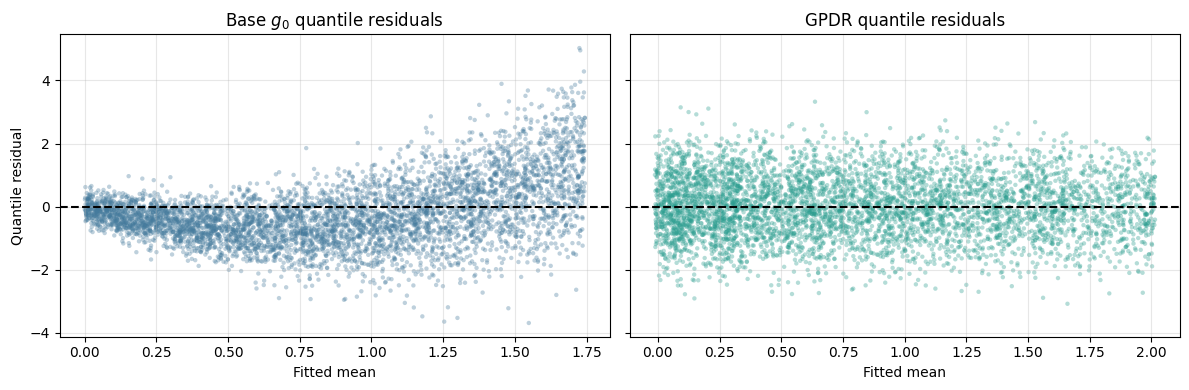

In [13]:
@torch.no_grad()
def quantile_residual_diagnostic_toy(model, y_min=-0.3, y_max=3.0, M=1500, eps=1e-10):
    """Compute quantile residuals for GPDR and the normal base model g_0."""
    gpdr_pit = []
    gpdr_mean = []
    base_pit = []
    base_mean = []

    x_np = model.x.detach().cpu().numpy()
    y_np = model.y.detach().cpu().numpy()

    for x_i, y_i in zip(x_np, y_np):
        y_grid, _, h_hat, _, _ = model.predict_density(float(x_i), y_min=y_min, y_max=y_max, M=M)

        dy = np.diff(y_grid)
        wts = np.zeros_like(y_grid)
        wts[0] = dy[0] / 2.0
        wts[-1] = dy[-1] / 2.0
        wts[1:-1] = (dy[:-1] + dy[1:]) / 2.0

        prob = h_hat * wts
        prob = prob / prob.sum()
        cdf = np.cumsum(prob)
        cdf = np.clip(cdf, 0.0, 1.0)

        pit_i = np.interp(y_i, y_grid, cdf)
        gpdr_pit.append(pit_i)
        gpdr_mean.append(float(np.sum(y_grid * prob)))

        mu_base_i = float(b_base * x_i)
        base_mean.append(mu_base_i)
        base_pit.append(norm.cdf(y_i, loc=mu_base_i, scale=ORIGINAL_SIGMA_NORMAL))

    gpdr_pit = np.clip(np.asarray(gpdr_pit), eps, 1.0 - eps)
    base_pit = np.clip(np.asarray(base_pit), eps, 1.0 - eps)
    gpdr_mean = np.asarray(gpdr_mean)
    base_mean = np.asarray(base_mean)

    gpdr_resid = norm.ppf(gpdr_pit)
    base_resid = norm.ppf(base_pit)

    return {
        "gpdr": {
            "pit": gpdr_pit,
            "quantile_residual": gpdr_resid,
            "fitted_mean": gpdr_mean,
            "summary": {
                "mean": float(np.mean(gpdr_resid)),
                "std": float(np.std(gpdr_resid, ddof=1)),
                "q05": float(np.quantile(gpdr_resid, 0.05)),
                "median": float(np.quantile(gpdr_resid, 0.50)),
                "q95": float(np.quantile(gpdr_resid, 0.95)),
            },
        },
        "base_g0": {
            "pit": base_pit,
            "quantile_residual": base_resid,
            "fitted_mean": base_mean,
            "summary": {
                "mean": float(np.mean(base_resid)),
                "std": float(np.std(base_resid, ddof=1)),
                "q05": float(np.quantile(base_resid, 0.05)),
                "median": float(np.quantile(base_resid, 0.50)),
                "q95": float(np.quantile(base_resid, 0.95)),
            },
        },
    }

qr_diag = quantile_residual_diagnostic_toy(model)

print("Toy quantile residual diagnostics")
print("=" * 70)
for model_name, payload in qr_diag.items():
    print()
    print(model_name)
    for key, value in payload["summary"].items():
        print(f"  {key:>6s}: {value:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_specs = [
    ("base_g0", axes[0], r"Base $g_0$ quantile residuals", "#457B9D"),
    ("gpdr", axes[1], "GPDR quantile residuals", "#2A9D8F"),
]

for key, ax, title, color in plot_specs:
    fitted_mean = qr_diag[key]["fitted_mean"]
    residual = qr_diag[key]["quantile_residual"]
    ax.scatter(fitted_mean, residual, s=10, alpha=0.35, color=color, edgecolors="none")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Fitted mean")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Quantile residual")
plt.tight_layout()
plt.savefig("toy_quantile_residuals_vs_fitted_mean.pdf", dpi=220, bbox_inches="tight")
plt.show()


### Benchmark Specifications

All benchmarks reuse the GPDR training and test observations. Fitting uses package defaults except for the explicit settings below; response families and formulas specify the competing models.

- **GAMLSS:** Gaussian family, with `y ~ pb(x)` for the mean and `sigma.formula = ~ pb(x)` for the scale. `pb` is a penalized B-spline smooth, allowing both parameters to vary with `x`.
- **TRAM:** `BoxCox(y | x ~ 1, order=6)`, allowing the response transformation to depend on `x`.
- **QRF:** `quantile_forest(X=x, Y=y)` with the default forest tuning settings; the seed and thread count are fixed for reproducibility.
- **DDPstar:** `y ~ f(x)`, where `f` is the package's default P-spline term. MCMC uses 1,000 burn-in and 1,000 retained draws (`nskip=1`), rather than the package defaults of 2,000 and 8,000, to reduce runtime.

The QRF log score retained in this notebook uses a Sturges-bin frequency polygon with Perks smoothing; it is an additional density approximation, not the forest's native probability mass.


### GAMLSS Benchmark

In [47]:
# Prepare GAMLSS benchmark data from the exact same GPDR train/test split.
# No new train/test split is created here.

import pandas as pd
import numpy as np

x_train_np = x.detach().cpu().numpy().reshape(-1)
y_train_np = y.detach().cpu().numpy().reshape(-1)
x_test_np = x_test.detach().cpu().numpy().reshape(-1)
y_test_np = y_test.detach().cpu().numpy().reshape(-1)

benchmark_train_toy = pd.DataFrame({
    "x": x_train_np,
    "y": y_train_np,
})

benchmark_test_toy = pd.DataFrame({
    "x": x_test_np,
    "y": y_test_np,
})

print("GAMLSS train shape:", benchmark_train_toy.shape)
print("GAMLSS test shape: ", benchmark_test_toy.shape)


GAMLSS train shape: (5000, 2)
GAMLSS test shape:  (50000, 2)


In [48]:
# Load R bridge for the GAMLSS benchmark.
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [49]:
%%R -i benchmark_train_toy -i benchmark_test_toy -o gamlss_toy_metrics -o gamlss_toy_density_examples

suppressPackageStartupMessages({
    library(gamlss)
    library(gamlss.dist)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_toy)
test_df <- as.data.frame(benchmark_test_toy)

fit_gamlss_toy <- gamlss(
    y ~ pb(x),
    sigma.formula = ~ pb(x),
    family = NO(),
    data = train_df,
    trace = FALSE
)

prediction_start <- Sys.time()
xt <- data.frame(x = test_df$x)
yt <- test_df$y

mu_t <- predict(fit_gamlss_toy, what = "mu", newdata = xt, type = "response")
sigma_t <- predict(fit_gamlss_toy, what = "sigma", newdata = xt, type = "response")
sigma_t <- pmax(sigma_t, 1e-8)

log_score <- sum(dNO(yt, mu = mu_t, sigma = sigma_t, log = TRUE))
rmse_mean <- sqrt(mean((yt - mu_t)^2))

lower <- qNO(0.025, mu = mu_t, sigma = sigma_t)
upper <- qNO(0.975, mu = mu_t, sigma = sigma_t)
coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

gamlss_toy_metrics <- data.frame(
    method = "GAMLSS Gaussian",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same x values used in the toy density panels.
x_values <- c(0.3, 0.5, 0.7)
y_grid <- seq(-0.3, 3.0, length.out = 600)
plot_df <- data.frame(x = x_values)
mu_plot <- predict(fit_gamlss_toy, what = "mu", newdata = plot_df, type = "response")
sigma_plot <- predict(fit_gamlss_toy, what = "sigma", newdata = plot_df, type = "response")
sigma_plot <- pmax(sigma_plot, 1e-8)

gamlss_toy_density_examples <- data.frame()
for (j in seq_along(x_values)) {
    dens <- dNO(y_grid, mu = mu_plot[j], sigma = sigma_plot[j])
    gamlss_toy_density_examples <- rbind(
        gamlss_toy_density_examples,
        data.frame(example = j, x = x_values[j], y_grid = y_grid, density = dens)
    )
}

print(gamlss_toy_metrics)



           method log_score rmse_mean coverage95 avg_width95 prediction_time
1 GAMLSS Gaussian  28136.28 0.1614069    0.94596   0.5832954           0.39s


In [50]:
# Compare GPDR and the first benchmark distributional regression model.
# GPDR metrics are taken from the GPDR evaluation cells above.

if 'coverage_updated' not in globals() or 'length_updated' not in globals() or 'gpdr_prediction_time' not in globals():
    raise RuntimeError("Run the GPDR metric cells first so GPDR metrics and prediction_time are available.")

gpdr_reference_toy = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(estimated_log_density_vals)],
    "rmse_mean": [float(rmse_updated)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_comparison_toy_first = pd.concat(
    [gpdr_reference_toy, gamlss_toy_metrics],
    ignore_index=True,
)

benchmark_comparison_toy_first



,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,27910.203162,0.161509,0.95330,0.606122,2m 21s
1,GAMLSS Gaussian,28136.275577,0.161407,0.94596,0.583295,0.39s


### TRAM Benchmark

In [51]:
%%R -i benchmark_train_toy -i benchmark_test_toy -o tram_toy_metrics -o tram_toy_density_examples

suppressPackageStartupMessages({
    library(tram)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_toy)
test_df <- as.data.frame(benchmark_test_toy)

fit_tram_toy <- BoxCox(
    y | x ~ 1,
    data = train_df,
    order = 6
)

xt <- data.frame(x = test_df$x)
yt <- test_df$y

# Log score: compute in chunks to avoid forming a full n_test by n_test density matrix.
tram_log_score_chunks <- function(fit, xt, yt, chunk_size = 1000L, eps = 1e-12) {
    n <- length(yt)
    out <- numeric(n)
    starts <- seq.int(1L, n, by = chunk_size)
    for (s in starts) {
        e <- min(s + chunk_size - 1L, n)
        idx <- s:e
        dens_mat <- predict(fit, newdata = xt[idx, , drop = FALSE], q = yt[idx], type = "density")
        dens_mat <- as.matrix(dens_mat)
        if (nrow(dens_mat) == length(idx) && ncol(dens_mat) == length(idx)) {
            dens_diag <- diag(dens_mat)
        } else if (nrow(dens_mat) == length(idx) && ncol(dens_mat) == 1L) {
            dens_diag <- as.numeric(dens_mat[, 1])
        } else if (nrow(dens_mat) == 1L && ncol(dens_mat) == length(idx)) {
            dens_diag <- as.numeric(dens_mat[1, ])
        } else {
            stop(sprintf("Unexpected TRAM observed-density shape: %d x %d", nrow(dens_mat), ncol(dens_mat)))
        }
        out[idx] <- log(pmax(dens_diag, eps))
    }
    sum(out)
}

prediction_start <- Sys.time()
log_score <- tram_log_score_chunks(fit_tram_toy, xt, yt)

# TRAM does not provide a closed-form conditional mean, so approximate it on a grid.
q_grid <- seq(min(train_df$y, test_df$y) - 1, max(train_df$y, test_df$y) + 1, length.out = 800)
dy <- q_grid[2] - q_grid[1]
tram_batch_size <- 1000L
n_test_tram <- length(yt)
est_mean <- numeric(n_test_tram)

for (start_idx in seq(1L, n_test_tram, by = tram_batch_size)) {
    end_idx <- min(start_idx + tram_batch_size - 1L, n_test_tram)
    idx <- start_idx:end_idx
    dens_grid <- predict(fit_tram_toy, newdata = xt[idx, , drop = FALSE], q = q_grid, type = "density")
    dens_grid <- as.matrix(dens_grid)
    if (nrow(dens_grid) == length(idx) && ncol(dens_grid) == length(q_grid)) {
        dens_grid <- t(dens_grid)
    }
    if (!(nrow(dens_grid) == length(q_grid) && ncol(dens_grid) == length(idx))) {
        stop(sprintf("Unexpected TRAM density grid shape: %d x %d", nrow(dens_grid), ncol(dens_grid)))
    }
    mass <- pmax(colSums(dens_grid) * dy, 1e-12)
    est_mean[idx] <- (colSums(dens_grid * q_grid) * dy) / mass
}

rmse_mean <- sqrt(mean((yt - est_mean)^2))

qs <- predict(fit_tram_toy, newdata = xt, prob = c(0.025, 0.975), type = "quantile")
qs <- as.matrix(qs)
if (nrow(qs) == 2L && ncol(qs) == length(yt)) {
    lower <- as.numeric(qs[1, ])
    upper <- as.numeric(qs[2, ])
} else if (nrow(qs) == length(yt) && ncol(qs) == 2L) {
    lower <- as.numeric(qs[, 1])
    upper <- as.numeric(qs[, 2])
} else {
    qs_vec <- as.numeric(qs)
    lower <- qs_vec[seq(1L, length(qs_vec), by = 2L)]
    upper <- qs_vec[seq(2L, length(qs_vec), by = 2L)]
}

coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

tram_toy_metrics <- data.frame(
    method = "TRAM BoxCox",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same x values used in the toy density panels.
x_values <- c(0.3, 0.5, 0.7)
y_grid <- seq(-0.3, 3.0, length.out = 600)
tram_toy_density_examples <- data.frame()
for (j in seq_along(x_values)) {
    dens <- as.numeric(predict(
        fit_tram_toy,
        newdata = data.frame(x = x_values[j]),
        q = y_grid,
        type = "density"
    ))
    tram_toy_density_examples <- rbind(
        tram_toy_density_examples,
        data.frame(example = j, x = x_values[j], y_grid = y_grid, density = dens)
    )
}

print(tram_toy_metrics)



       method log_score rmse_mean coverage95 avg_width95 prediction_time
1 TRAM BoxCox  25787.87  0.161982  0.9458833   0.5994995           9.68s


### Quantile Regression Forest Benchmark

In [52]:
%%R -i benchmark_train_toy -i benchmark_test_toy -o qrf_toy_metrics -o qrf_toy_density_examples

suppressPackageStartupMessages({
    library(grf)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_toy)
test_df <- as.data.frame(benchmark_test_toy)

Xtr <- as.matrix(train_df[, "x", drop = FALSE])
ytr <- train_df$y
Xte <- as.matrix(test_df[, "x", drop = FALSE])
yt <- test_df$y

set.seed(2)
fit_qrf_toy <- quantile_forest(
    Xtr,
    ytr,
    seed = 2,
    num.threads = 4
)

# QRF gives a weighted empirical conditional distribution rather than a smooth
# continuous density. For a density-scale log score we smooth only the evaluation
# distribution, not the QRF fit. Sturges' rule sets the number of bins; a
# frequency polygon linearly interpolates the weighted bin heights; and Perks'
# symmetric Dirichlet prior, alpha = 1/K per bin, avoids zero bin probabilities.
n_train_qrf <- length(ytr)
y_range_qrf <- range(ytr)
# Use Sturges' rule to choose the number of bins.
n_bins_qrf <- ceiling(log2(n_train_qrf) + 1)
breaks_qrf <- seq(y_range_qrf[1], y_range_qrf[2], length.out = n_bins_qrf + 1L)
centers_qrf <- (breaks_qrf[-1] + breaks_qrf[-length(breaks_qrf)]) / 2
bin_width_qrf <- diff(breaks_qrf)[1]
ytr_bin_qrf <- findInterval(ytr, breaks_qrf, all.inside = TRUE)
alpha_per_bin_qrf <- 1 / n_bins_qrf

qrf_batch_size <- 500L
n_test_qrf <- nrow(Xte)
density_at_observed <- numeric(n_test_qrf)
qrf_mean <- numeric(n_test_qrf)

prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_qrf, by = qrf_batch_size)) {
    end_idx <- min(start_idx + qrf_batch_size - 1L, n_test_qrf)
    idx <- start_idx:end_idx

    W_batch <- as.matrix(get_forest_weights(
        fit_qrf_toy,
        newdata = Xte[idx, , drop = FALSE]
    ))

    qrf_mean[idx] <- as.numeric(W_batch %*% ytr)
    n_eff_batch <- 1 / rowSums(W_batch^2)

    bin_heights <- matrix(0, nrow = length(idx), ncol = n_bins_qrf)
    for (b in seq_len(n_bins_qrf)) {
        raw_mass_b <- rowSums(W_batch[, ytr_bin_qrf == b, drop = FALSE])
        smooth_mass_b <- (n_eff_batch * raw_mass_b + alpha_per_bin_qrf) /
            (n_eff_batch + alpha_per_bin_qrf * n_bins_qrf)
        bin_heights[, b] <- smooth_mass_b / bin_width_qrf
    }

    for (ii in seq_along(idx)) {
        density_at_observed[idx[ii]] <- approx(
            centers_qrf,
            bin_heights[ii, ],
            xout = yt[idx[ii]],
            rule = 2,
            ties = "ordered"
        )$y
    }
}

log_score <- sum(log(pmax(density_at_observed, .Machine$double.xmin)))
rmse_mean <- sqrt(mean((yt - qrf_mean)^2))

qrf_interval <- predict(fit_qrf_toy, Xte, quantiles = c(0.025, 0.975))$predictions
qrf_interval <- as.matrix(qrf_interval)
lower <- qrf_interval[, 1]
upper <- qrf_interval[, 2]

coverage95 <- mean(yt >= lower & yt <= upper, na.rm = TRUE)
avg_width95 <- mean(upper - lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

qrf_toy_metrics <- data.frame(
    method = "Quantile RF",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

cat(sprintf("QRF Sturges frequency-polygon bins: %d\n", n_bins_qrf))
cat(sprintf("QRF Perks smoothing alpha per bin: %.6f\n", alpha_per_bin_qrf))
cat(sprintf("QRF non-finite/non-positive densities: %d / %d\n", sum(!is.finite(density_at_observed) | density_at_observed <= 0), n_test_qrf))

# Frequency-polygon predictive density examples at the same x values used in the toy density panels.
x_values <- c(0.3, 0.5, 0.7)
y_grid <- seq(-0.3, 3.0, length.out = 600)
qrf_toy_density_examples <- data.frame()

for (j in seq_along(x_values)) {
    w_row <- as.numeric(get_forest_weights(
        fit_qrf_toy,
        newdata = matrix(x_values[j], nrow = 1, ncol = 1)
    ))
    n_eff_row <- 1 / sum(w_row^2)

    bin_heights <- numeric(n_bins_qrf)
    for (b in seq_len(n_bins_qrf)) {
        raw_mass_b <- sum(w_row[ytr_bin_qrf == b])
        smooth_mass_b <- (n_eff_row * raw_mass_b + alpha_per_bin_qrf) /
            (n_eff_row + alpha_per_bin_qrf * n_bins_qrf)
        bin_heights[b] <- smooth_mass_b / bin_width_qrf
    }

    dens <- approx(
        centers_qrf,
        bin_heights,
        xout = y_grid,
        rule = 2,
        ties = "ordered"
    )$y

    qrf_toy_density_examples <- rbind(
        qrf_toy_density_examples,
        data.frame(example = j, x = x_values[j], y_grid = y_grid, density = dens)
    )
}

print(qrf_toy_metrics)


QRF Sturges frequency-polygon bins: 14
QRF Perks smoothing alpha per bin: 0.071429
QRF non-finite/non-positive densities: 0 / 50000
       method log_score rmse_mean coverage95 avg_width95 prediction_time
1 Quantile RF  21267.12 0.1645327     0.9041   0.5493069          27.94s


In [53]:
# Compare GPDR and all three benchmark distributional regression models.
# GPDR metrics are taken from the GPDR evaluation cells above.

if 'coverage_updated' not in globals() or 'length_updated' not in globals() or 'gpdr_prediction_time' not in globals():
    raise RuntimeError("Run the GPDR metric cells first so GPDR metrics and prediction_time are available.")

gpdr_reference_toy = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(estimated_log_density_vals)],
    "rmse_mean": [float(rmse_updated)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_comparison_toy_all = pd.concat(
    [gpdr_reference_toy, gamlss_toy_metrics, tram_toy_metrics, qrf_toy_metrics],
    ignore_index=True,
)

benchmark_comparison_toy_all



,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,27910.203162,0.161509,0.953300,0.606122,2m 21s
1,GAMLSS Gaussian,28136.275577,0.161407,0.945960,0.583295,0.39s
2,TRAM BoxCox,25787.874156,0.161982,0.945883,0.599500,9.68s
3,Quantile RF,21267.120623,0.164533,0.904100,0.549307,27.94s


### DDPstar Benchmark

In [27]:
%%R -i benchmark_train_toy -i benchmark_test_toy -o ddpstar_toy_metrics -o ddpstar_toy_density_examples

suppressPackageStartupMessages({
    library(DDPstar)
})

format_prediction_time <- function(seconds) {
    seconds <- as.numeric(seconds)
    if (seconds < 60) {
        return(sprintf("%.2fs", seconds))
    }
    minutes <- floor(seconds / 60)
    sec <- round(seconds - 60 * minutes)
    if (minutes < 60) {
        return(sprintf("%dm %.0fs", minutes, sec))
    }
    hours <- floor(minutes / 60)
    minutes <- minutes - 60 * hours
    sprintf("%dh %dm %.0fs", hours, minutes, sec)
}

train_df <- as.data.frame(benchmark_train_toy)
test_df <- as.data.frame(benchmark_test_toy)

set.seed(2)
fit_ddpstar_toy <- DDPstar(
    y ~ f(x, nseg = 5, bdeg = 3, pord = 2, atau = 1, btau = 0.005),
    data = train_df,
    prior = list(a = 2, b = 0.5, aalpha = 2, balpha = 2, L = 10),
    mcmc = list(nburn = 1000, nsave = 1000, nskip = 1),
    standardise = TRUE,
    verbose = FALSE
)

xt <- data.frame(x = test_df$x)
yt <- test_df$y
n_test_ddp <- length(yt)

ddpstar_mean <- numeric(n_test_ddp)
ddpstar_lower <- numeric(n_test_ddp)
ddpstar_upper <- numeric(n_test_ddp)
ddpstar_density_at_observed <- numeric(n_test_ddp)

# A common grid for fallback interval calculation if DDPstar's quantfun root finder
# fails on a batch. The grid is deliberately wider than the observed toy range.
ddp_y_grid <- seq(min(c(train_df$y, test_df$y)) - 0.75, max(c(train_df$y, test_df$y)) + 0.75, length.out = 900)
ddp_dy <- ddp_y_grid[2] - ddp_y_grid[1]

ddpstar_density_diag <- function(fit, newdata_batch, y_batch, eps = 1e-12) {
    pred_den <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = y_batch,
        parallel = "no"
    )$denfun
    d <- dim(pred_den)
    if (length(d) != 3L) {
        stop("Unexpected DDPstar denfun output: expected a 3D array.")
    }
    out <- numeric(length(y_batch))
    for (j in seq_along(y_batch)) {
        out[j] <- mean(pred_den[j, j, ], na.rm = TRUE)
    }
    pmax(out, eps)
}

ddpstar_grid_intervals <- function(fit, newdata_batch, probs = c(0.025, 0.975)) {
    pred_grid <- predict(
        fit,
        newdata = newdata_batch,
        what = "denfun",
        den.grid = ddp_y_grid,
        parallel = "no"
    )$denfun
    den_mean <- apply(pred_grid, c(1, 2), mean, na.rm = TRUE)
    if (is.null(dim(den_mean))) {
        den_mean <- matrix(den_mean, nrow = length(ddp_y_grid), ncol = 1L)
    }
    if (nrow(den_mean) != length(ddp_y_grid)) {
        den_mean <- t(den_mean)
    }
    lower <- numeric(ncol(den_mean))
    upper <- numeric(ncol(den_mean))
    for (j in seq_len(ncol(den_mean))) {
        dens <- pmax(den_mean[, j], 0)
        mass <- sum(dens) * ddp_dy
        if (!is.finite(mass) || mass <= 0) {
            lower[j] <- NA_real_
            upper[j] <- NA_real_
        } else {
            cdf <- cumsum(dens) * ddp_dy / mass
            lower[j] <- approx(cdf, ddp_y_grid, xout = probs[1], ties = "ordered", rule = 2)$y
            upper[j] <- approx(cdf, ddp_y_grid, xout = probs[2], ties = "ordered", rule = 2)$y
        }
    }
    list(lower = lower, upper = upper)
}

# Predictions are evaluated in smaller chunks because the toy test set has 50,000 points
# and DDPstar temporarily forms batch-by-batch-by-MCMC arrays for density prediction.
ddpstar_batch_size <- 100L
prediction_start <- Sys.time()
for (start_idx in seq(1L, n_test_ddp, by = ddpstar_batch_size)) {
    end_idx <- min(start_idx + ddpstar_batch_size - 1L, n_test_ddp)
    idx <- start_idx:end_idx
    new_batch <- xt[idx, , drop = FALSE]
    y_batch <- yt[idx]

    pred_reg <- predict(
        fit_ddpstar_toy,
        newdata = new_batch,
        what = "regfun",
        parallel = "no"
    )$regfun
    ddpstar_mean[idx] <- rowMeans(pred_reg, na.rm = TRUE)

    quant_ok <- TRUE
    pred_q <- tryCatch(
        predict(
            fit_ddpstar_toy,
            newdata = new_batch,
            what = "quantfun",
            quant.probs = c(0.025, 0.975),
            parallel = "no"
        )$quantfun,
        error = function(e) {
            quant_ok <<- FALSE
            NULL
        }
    )
    if (quant_ok) {
        ddpstar_lower[idx] <- apply(pred_q[, , 1, drop = FALSE], 1, median, na.rm = TRUE)
        ddpstar_upper[idx] <- apply(pred_q[, , 2, drop = FALSE], 1, median, na.rm = TRUE)
    } else {
        grid_q <- ddpstar_grid_intervals(fit_ddpstar_toy, new_batch)
        ddpstar_lower[idx] <- grid_q$lower
        ddpstar_upper[idx] <- grid_q$upper
    }

    ddpstar_density_at_observed[idx] <- ddpstar_density_diag(
        fit_ddpstar_toy,
        new_batch,
        y_batch
    )

    if (start_idx == 1L || end_idx == n_test_ddp || start_idx %% 5000L == 1L) {
        cat(sprintf("DDPstar prediction progress: %d / %d\n", end_idx, n_test_ddp))
    }
}

log_score <- sum(log(pmax(ddpstar_density_at_observed, 1e-12)))
rmse_mean <- sqrt(mean((yt - ddpstar_mean)^2, na.rm = TRUE))
coverage95 <- mean(yt >= ddpstar_lower & yt <= ddpstar_upper, na.rm = TRUE)
avg_width95 <- mean(ddpstar_upper - ddpstar_lower, na.rm = TRUE)
prediction_time <- format_prediction_time(difftime(Sys.time(), prediction_start, units = "secs"))

ddpstar_toy_metrics <- data.frame(
    method = "DDPstar",
    log_score = log_score,
    rmse_mean = rmse_mean,
    coverage95 = coverage95,
    avg_width95 = avg_width95,
    prediction_time = prediction_time
)

# Predictive densities at the same x values used in the toy density panels.
x_values <- c(0.3, 0.5, 0.7)
y_grid <- seq(-0.3, 3.0, length.out = 600)
pred_plot <- predict(
    fit_ddpstar_toy,
    newdata = data.frame(x = x_values),
    what = "denfun",
    den.grid = y_grid,
    parallel = "no"
)$denfun
plot_den_mean <- apply(pred_plot, c(1, 2), mean, na.rm = TRUE)

ddpstar_toy_density_examples <- data.frame()
for (j in seq_along(x_values)) {
    ddpstar_toy_density_examples <- rbind(
        ddpstar_toy_density_examples,
        data.frame(example = j, x = x_values[j], y_grid = y_grid, density = plot_den_mean[, j])
    )
}

print(ddpstar_toy_metrics)



DDPstar prediction progress: 100 / 50000
DDPstar prediction progress: 5100 / 50000
DDPstar prediction progress: 10100 / 50000
DDPstar prediction progress: 15100 / 50000
DDPstar prediction progress: 20100 / 50000
DDPstar prediction progress: 25100 / 50000
DDPstar prediction progress: 30100 / 50000
DDPstar prediction progress: 35100 / 50000
DDPstar prediction progress: 40100 / 50000
DDPstar prediction progress: 45100 / 50000
DDPstar prediction progress: 50000 / 50000
   method log_score rmse_mean coverage95 avg_width95 prediction_time
1 DDPstar  27225.88 0.1614525    0.94954   0.5878931       3h 3m 32s


### Benchmark Metric Comparison: All Methods Including DDPstar

This final table keeps the same GPDR reference metrics and adds DDPstar as the fourth benchmark, again using the same held-out toy test observations.

In [54]:
# Compare GPDR and all benchmark distributional regression models, including DDPstar.
# GPDR metrics are taken from the GPDR evaluation cells above.
# Prediction time records held-out metric evaluation after fitting.

if 'coverage_updated' not in globals() or 'length_updated' not in globals() or 'gpdr_prediction_time' not in globals():
    raise RuntimeError("Run the GPDR metric cells first so GPDR metrics and prediction_time are available.")

gpdr_reference_toy = pd.DataFrame({
    "method": ["GPDR"],
    "log_score": [float(estimated_log_density_vals)],
    "rmse_mean": [float(rmse_updated)],
    "coverage95": [float(coverage_updated)],
    "avg_width95": [float(length_updated)],
    "prediction_time": [gpdr_prediction_time],
})

benchmark_frames = [
    gpdr_reference_toy,
    gamlss_toy_metrics,
    tram_toy_metrics,
    qrf_toy_metrics,
    ddpstar_toy_metrics,
]

for frame in benchmark_frames:
    if "prediction_time" not in frame.columns:
        raise RuntimeError("A benchmark metric table is missing prediction_time. Re-run that benchmark cell.")

benchmark_comparison_toy_all = pd.concat(
    benchmark_frames,
    ignore_index=True,
)[["method", "log_score", "rmse_mean", "coverage95", "avg_width95", "prediction_time"]]

benchmark_comparison_toy_all



,method,log_score,rmse_mean,coverage95,avg_width95,prediction_time
0,GPDR,27910.203162,0.161509,0.953300,0.606122,2m 21s
1,GAMLSS Gaussian,28136.275577,0.161407,0.945960,0.583295,0.39s
2,TRAM BoxCox,25787.874156,0.161982,0.945883,0.599500,9.68s
3,Quantile RF,21267.120623,0.164533,0.904100,0.549307,27.94s
4,DDPstar,27225.877652,0.161452,0.949540,0.587893,3h 3m 32s
